# The Langevin generalized Lotka--Volterra model

A minimal model of firm growth. Many firms compete and cooperate on a sparse random network and
grow with **demographic noise** (smaller firms fluctuate more). Operated just below a critical
cooperation strength, the model reproduces the two Moran--Secchi--Bouchaud (MSB) stylized facts of
firm growth:

- a **size--volatility** power law $\sigma_i \propto S_i^{-\beta}$, with $\beta$ near the empirical $0.15$--$0.20$;
- a **fat-tailed (tent-shaped) growth-rate distribution**.

This notebook states the model, integrates one realization, and reads off the two observables.
Parameter sweeps (noise level $\bar n$, distance to $\mu_c$, system size $N$) live in
`langevin_glv_sweeps.ipynb` to keep this one clean.

## The model

**1. Deterministic GLV.** Firm sizes $x_i$ ($i=1,\dots,N$) follow
$$\frac{dx_i}{dt} = x_i\big[\,1 - x_i + (Wx)_i\,\big],$$
logistic self-limitation $(1-x_i)$ plus interactions through a sparse random matrix $W$ on a
power-law graph, with each edge
$$W_{ij} = \frac{\mu}{C} + \frac{\sigma}{\sqrt{C}}\,z_{ij},\qquad z_{ij}\sim\mathcal{N}(0,1)$$
(mean degree $C$, cooperation strength $\mu$, disorder $\sigma$).

**2. Demographic noise --- where the stochasticity enters.** Firm $i$ is a population of $n_i$
individuals; demographic fluctuations make its per-capita growth rate jitter with variance
$\propto 1/n_i$. We tie the head-count to the firm's relative size,
$$n_i = \bar n\,S_i,\qquad S_i = N y_i\ \ (\langle S\rangle = 1),$$
so $\bar n$ is the number of individuals in a mean-size firm (fixed, independent of $N$). The noise
multiplies each firm's growth:
$$d\ln x_i = \big[\,1 - x_i + (Wx)_i\,\big]\,dt \;+\; \frac{\sigma_d}{\sqrt{n_i}}\,dW_i \;-\; \frac{\sigma_d^2}{2\,n_i}\,dt,\qquad \langle dW_i\,dW_j\rangle = \delta_{ij}\,dt.$$
The middle term is the demographic noise: amplitude $\sigma_d/\sqrt{n_i}\propto S_i^{-1/2}$, so
**small firms are noisier** (the $\sigma\propto S^{-1/2}$ baseline). The last term is the Ito
correction that keeps the noise mean-preserving for $x_i$.

**3. Rescaling (keeps the integration bounded near $\mu_c$).** Split size into an overall scale
and a shape on the simplex,
$$x_i = M\,y_i,\qquad \sum_i y_i = 1,\qquad d\tau = M\,dt.$$
The deterministic parts become (with $F=Wy$, $\varphi = y\!\cdot\!Wy$):
$$\frac{dy_i}{d\tau} = y_i\big(F_i - \varphi - y_i + \textstyle\sum_k y_k^2\big),\qquad
  \frac{dM}{d\tau} = 1 + M\big(\varphi - \textstyle\sum_k y_k^2\big).$$
$M$ carries the common growth (finite while $\mu<\mu_c$, diverges at $\mu_c$); the **noise drives
the shape $y$** --- the cross-sectional reshuffling of relative sizes. Since $S = Ny$, the scale
$M$ cancels out of every observable. Numerically the noise is added in physical time
(amplitude $\propto\sqrt{dt}=\sqrt{d\tau/M}$), its common (size-shifting) mode is absorbed into $M$,
and the rest perturbs $y$.

**4. Observables.** From the yearly-sampled normalized sizes $S_i$: growth $g_i = \Delta\ln S_i$,
volatility $\sigma_i = \sqrt{\pi/2}\,\overline{|g-\bar g|}$, and the size--volatility exponent
$\beta$ in $\sigma_i \propto S_i^{-\beta}$.

In [13]:
import numpy as np, networkx as nx, scipy.sparse as sp
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.special import logsumexp
from scipy.stats import skew, kurtosis
import glv; glv.apply_style()                 # consistent plot style

# ---- model parameters ----
N      = 1000      # number of firms
C      = 100         # mean degree of the interaction graph
SIGMA  = 0.2       # interaction disorder       W_ij = mu/C + SIGMA/sqrt(C) * z_ij
ALPHA  = 2.5       # power-law degree exponent   P(k) ~ k^-ALPHA
FRAC   = 0.95      # operate at mu = FRAC * mu_c (just below critical -> bounded, near-critical)
SD     = 1.0       # demographic noise strength  sigma_d
NBAR   = 1.0       # individuals in a mean-size firm:  n_i = NBAR * N * y_i = NBAR * S_i

# ---- integration controls ----
DTAU    = 0.02     # rescaled-time step
TAU_MAX = 2.0e4    # total rescaled time
N_YEARS = 100      # number of yearly snapshots used for the observables
N_REC   = 4000     # number of trajectory samples to store
SEED    = 9002
rng = np.random.default_rng(SEED)
print(f"N={N}  C={C}  sigma={SIGMA}  mu={FRAC}*mu_c  sigma_d={SD}  nbar={NBAR}")

N=1000  C=100  sigma=0.2  mu=0.95*mu_c  sigma_d=1.0  nbar=1.0


## Build the network and interaction matrix

In [14]:
# Degree sequence -> configuration-model graph -> sparse interaction matrix W.
def power_law_degrees(N, C, alpha, rng):
    # N integer degrees drawn from P(k) ~ k^-alpha with mean degree ~ C
    kmin = C * (alpha - 2) / (alpha - 1)                 # choose kmin so that <k> = C
    k = kmin * (1.0 - rng.uniform(size=N)) ** (-1.0/(alpha - 1))
    return np.maximum(np.round(k).astype(int), 1)

# --- degree distribution: comment / uncomment one line to switch ---
# deg = power_law_degrees(N, C, ALPHA, rng)    # heavy-tailed:  P(k) ~ k^-ALPHA   (has hubs)
deg = np.full(N, C)                          # regular:        every firm has the same degree C

if deg.sum() % 2:                                        # configuration model needs an even degree sum
    deg[0] += 1
G = nx.Graph(nx.configuration_model(deg.tolist(), seed=SEED))
G.remove_edges_from(nx.selfloop_edges(G))
A = nx.to_scipy_sparse_array(G, format="csr", dtype=float).tocoo()
C_eff = float(A.sum(1).mean())                           # realized mean degree

# Random edge weights, frozen once:  W_ij = mu/C + (sigma/sqrt(C)) z_ij
z = rng.standard_normal(A.row.size)
def build_W(mu):
    return sp.csr_array((mu/C_eff + (SIGMA/np.sqrt(C_eff))*z, (A.row, A.col)), shape=A.shape)

print(f"realized mean degree <k> = {C_eff:.1f}   (edges: {A.row.size//2})")

realized mean degree <k> = 95.1   (edges: 47549)


## Locate the critical point $\mu_c$

$\mu_c$ is where the overall scale $M$ stops being bounded. Diagnostic: relax the shape $y$ at
fixed $\mu$ and compute the **shape scalar** $c(\mu) = y^\top W y - y^\top y$. Below $\mu_c$ it is
negative ($M$ settles to $1/|c|$); it crosses zero exactly at $\mu_c$.

In [ ]:
MUS = np.linspace(0.7, 1.0, 27)

def shape_scalar(W, tau=1e4):
    # relax the shape y under the deterministic flow and return c = y^T W y - y^T y
    def rhs(t, y):
        y = np.clip(y, 0, None); y = y / y.sum()
        F = W @ y
        return y * (F - y@F - y + y@y)
    sol = solve_ivp(rhs, (0, tau), np.full(N, 1/N), method="LSODA",
                    rtol=1e-8, atol=1e-10, t_eval=[tau])
    y = np.clip(sol.y[:, -1], 0, None); y /= y.sum()
    return float(y @ (W @ y) - y @ y)

cs = np.array([shape_scalar(build_W(m)) for m in MUS])
i  = np.where(np.diff(np.sign(cs)))[0][0]                       # bracket the zero crossing
mu_c = MUS[i] - cs[i]*(MUS[i+1]-MUS[i])/(cs[i+1]-cs[i])         # linear interpolation
mu   = FRAC * mu_c
print(f"mu_c = {mu_c:.3f}   ->   operating at mu = {FRAC} * mu_c = {mu:.3f}")

mu_c = 1.010   ->   operating at mu = 0.95 * mu_c = 0.960


## Integrate one realization

Euler--Maruyama in rescaled time $\tau$. The demographic-noise term is the heart of the model: it
is built in physical time ($dt=d\tau/M$), its common mode is projected out so it only reshuffles the
relative sizes, and the overall scale $M$ is advanced deterministically.

In [16]:
def integrate(W, seed):
    rng = np.random.default_rng(seed)
    y = np.full(N, 1/N)        # shape on the simplex (sum y = 1)
    M = 1.0                    # overall scale
    t_phys = 0.0               # physical time
    nstep = int(TAU_MAX / DTAU); every = max(nstep // N_REC, 1)
    t_rec, lnx_rec = [], []
    for it in range(nstep):
        F = W @ y; phi = float(y @ F); sumsq = float(y @ y)

        # --- demographic noise (physical time, dt = dtau / M) ---
        n_i = np.maximum(NBAR * N * y, 1.0)                      # individuals per firm (>= 1)
        dt  = DTAU / M
        noise = SD/np.sqrt(n_i)*np.sqrt(dt)*rng.standard_normal(N)   # sigma_d/sqrt(n_i) dW
        noise -= 0.5 * SD**2 / n_i * dt                             # Ito correction
        noise -= float(y @ noise)                                   # drop common mode -> shape only

        # --- shape update (deterministic drift + noise), then renormalise to the simplex ---
        ln_y = np.log(y) + (F - phi - y + sumsq) * DTAU + noise
        ln_y -= ln_y.max(); y = np.exp(np.clip(ln_y, -700, None)); y /= y.sum()

        # --- scale update (deterministic) ---
        M += (1.0 + M * (phi - sumsq)) * DTAU
        if not np.isfinite(M) or M <= 0:
            break
        t_phys += DTAU / M
        if it % every == 0:
            t_rec.append(t_phys)
            lnx_rec.append(np.log(M) + np.log(y))               # ln x_i = ln M + ln y_i
    return np.array(t_rec), np.array(lnx_rec).T                 # times, ln x_i(t) with shape (N, n_samples)

t, lnx = integrate(build_W(mu), SEED + 1)
print(f"integrated to physical time t = {t[-1]:.1f}  with {lnx.shape[1]} samples")

integrated to physical time t = 16.8  with 4000 samples


## Trajectories

The scale $M(t)$ settles (we are below $\mu_c$); the normalized sizes $S_i = N y_i$ keep
reshuffling under the demographic noise.

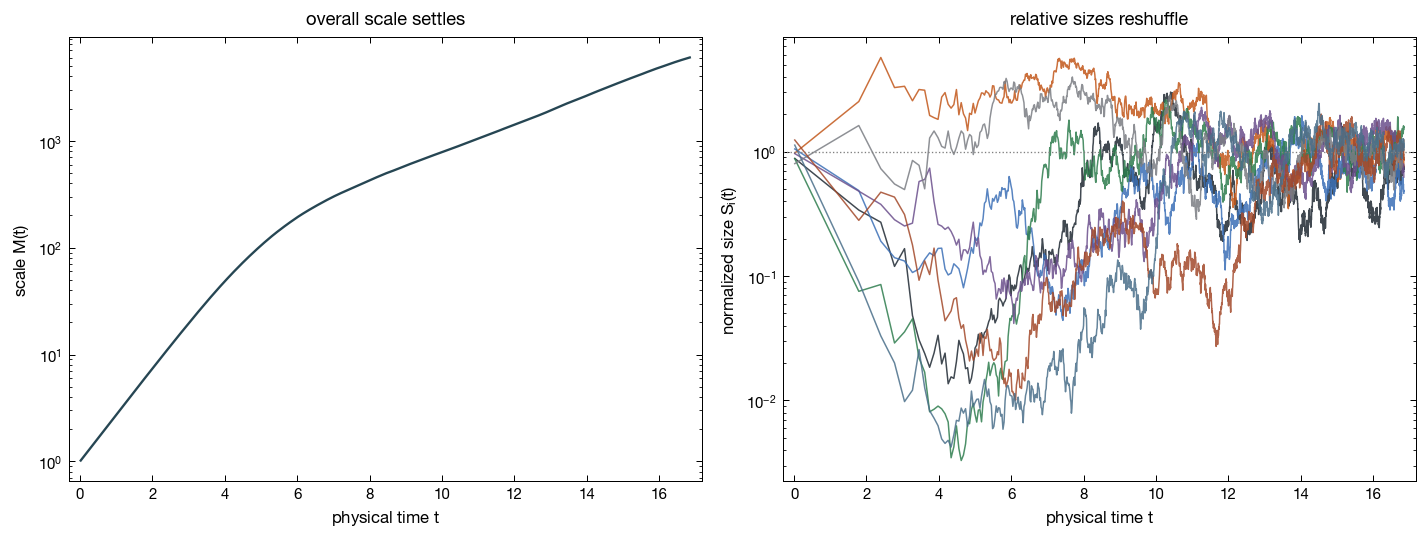

In [17]:
logS_t = lnx - logsumexp(lnx, axis=0, keepdims=True) + np.log(N)   # ln S_i(t), <S>=1 each instant
M_t    = np.exp(logsumexp(lnx, axis=0))                            # M(t) = sum_i x_i

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.6))
axL.semilogy(t, M_t, color="#264653"); axL.set(xlabel="physical time $t$", ylabel="scale $M(t)$",
                                               title="overall scale settles")
for i in rng.choice(N, 8, replace=False):
    axR.semilogy(t, np.exp(logS_t[i]), lw=0.9, alpha=0.85)
axR.axhline(1.0, color="gray", lw=0.8, ls=":")
axR.set(xlabel="physical time $t$", ylabel="normalized size $S_i(t)$", title="relative sizes reshuffle")
plt.tight_layout(); plt.savefig("langevin_glv_trajectories.png", dpi=120); plt.show()

## Observable 1 --- size--volatility

Resample on a uniform yearly grid, then for each firm take its time-average size $\bar S_i$ and its
volatility $\sigma_i=\sqrt{\pi/2}\,\overline{|g-\bar g|}$. A power-law fit on the bin medians gives
the exponent $\beta$.

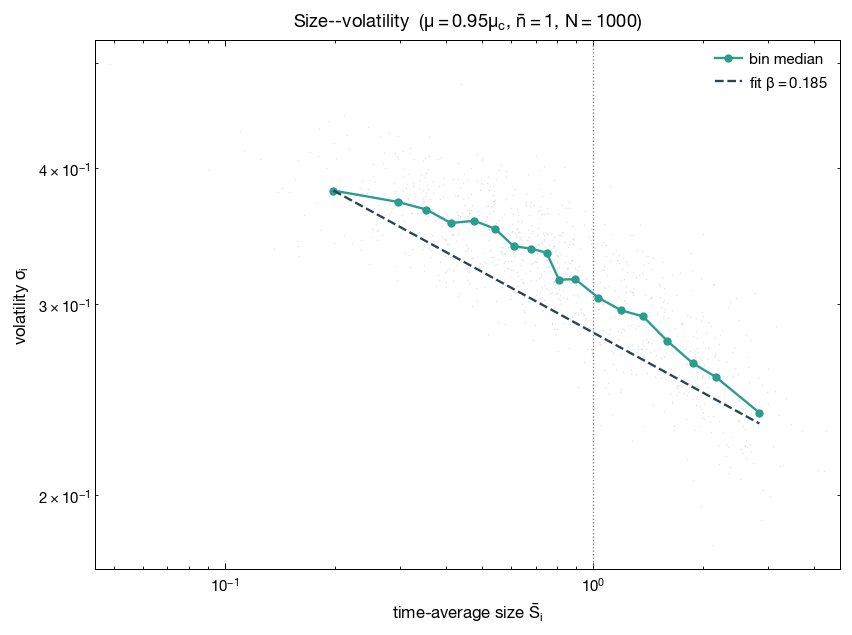

size-volatility exponent  beta = 0.185


In [18]:
# yearly resampling and per-firm observables
t_yr = np.linspace(t[0], t[-1], N_YEARS + 1)
lnx_yr = np.array([np.interp(t_yr, t, lnx[i]) for i in range(N)])
logS = lnx_yr - logsumexp(lnx_yr, axis=0, keepdims=True) + np.log(N)   # normalized size, yearly
g    = np.diff(logS, axis=1)                                          # growth g_i = Delta ln S_i
S_bar = np.exp(logS).mean(1)                                          # time-average size per firm
vol   = np.sqrt(np.pi/2) * np.abs(g - g.mean(1, keepdims=True)).mean(1)   # MAD volatility per firm

live = (S_bar > 1e-3) & (vol > 0) & np.isfinite(vol)                 # keep living firms
S_bar, vol = S_bar[live], vol[live]

def binned_median(x, y, nbins=18):
    o = np.argsort(x); xs, ys = x[o], y[o]
    parts = np.array_split(np.arange(len(xs)), nbins)
    return (np.array([xs[p].mean() for p in parts]),
            np.array([np.median(ys[p]) for p in parts]))

bx, by = binned_median(S_bar, vol)
m = (bx > 0) & (by > 0)
slope = np.polyfit(np.log10(bx[m]), np.log10(by[m]), 1)[0]
beta = -slope

fig, ax = plt.subplots(figsize=(7.2, 5.4))
ax.loglog(S_bar, vol, ".", ms=2, alpha=0.18, color="gray")
ax.loglog(bx[m], by[m], "o-", ms=5, color="#2a9d8f", label="bin median")
ax.loglog(bx[m], 10**np.polyval([slope, np.log10(by[m][0]) - slope*np.log10(bx[m][0])], np.log10(bx[m])),
          "--", color="#264653", label=fr"fit $\beta = {beta:.3f}$")
ax.axvline(1.0, color="gray", lw=0.8, ls=":")
ax.set(xlabel=r"time-average size $\bar S_i$", ylabel=r"volatility $\sigma_i$",
       title=fr"Size--volatility  ($\mu={FRAC}\mu_c$, $\bar n={NBAR:g}$, $N={N}$)")
ax.legend(); plt.tight_layout(); plt.savefig("langevin_glv_size_volatility.png", dpi=120); plt.show()
print(f"size-volatility exponent  beta = {beta:.3f}")

## Observable 2 --- growth-rate distribution

Pool the yearly growth rates $g=\Delta\ln S$ over all firms and years. Near $\mu_c$ the distribution
is **fat-tailed** (above the Gaussian, close to a Laplace tent). The survival (CCDF) panel resolves
the deep tails and shows their left/right asymmetry.

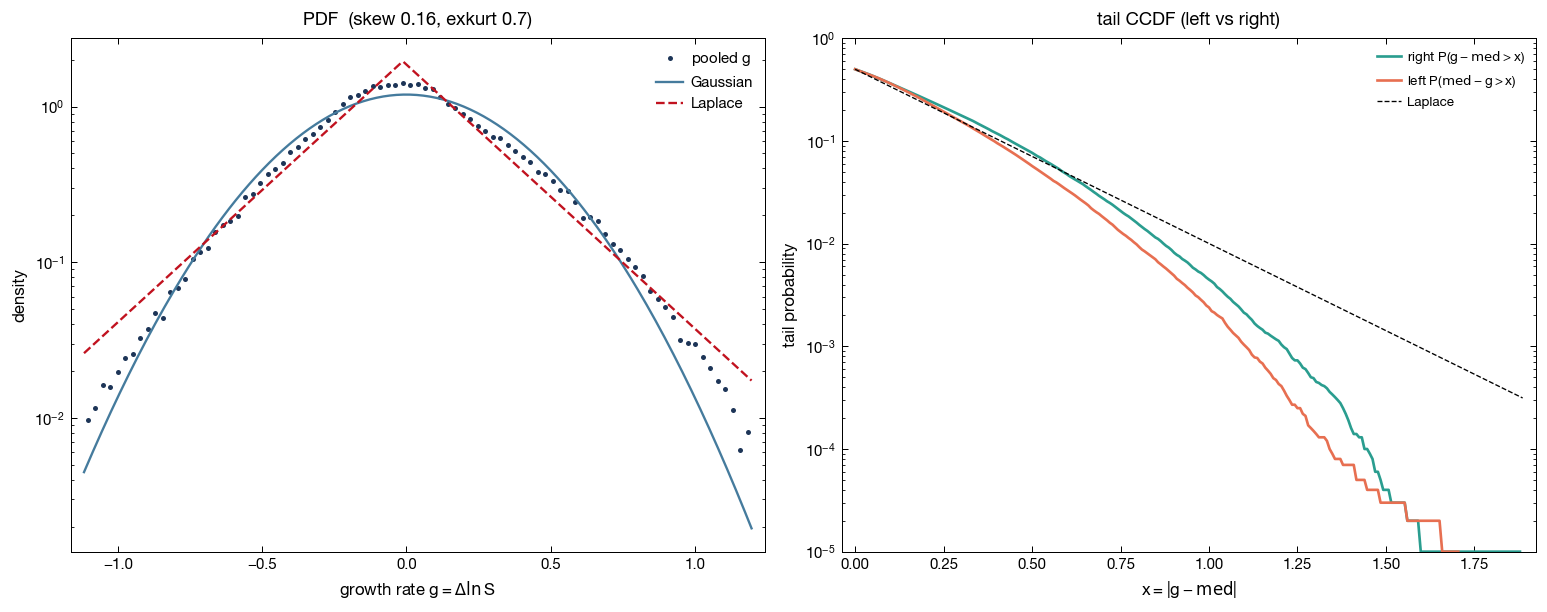

beta = 0.185   skew = +0.16   excess kurtosis = 0.7


In [19]:
gg = g.ravel(); gg = gg[np.isfinite(gg)]
sd = gg.std(); med = np.median(gg); b_lap = np.mean(np.abs(gg - med))   # Laplace scale

fig, (axP, axC) = plt.subplots(1, 2, figsize=(13, 5.2))

# --- PDF vs Gaussian and Laplace ---
lo, hi = np.percentile(gg, [0.1, 99.9]); e = np.linspace(lo, hi, 90); c = 0.5*(e[:-1]+e[1:])
dens, _ = np.histogram(gg, bins=e, density=True)
xx = np.linspace(lo, hi, 300)
axP.semilogy(c, np.where(dens > 0, dens, np.nan), "o", ms=3, color="#1d3557", label="pooled $g$")
axP.semilogy(xx, np.exp(-0.5*((xx-gg.mean())/sd)**2)/(sd*np.sqrt(2*np.pi)), "-", color="#457b9d", label="Gaussian")
axP.semilogy(xx, np.exp(-np.abs(xx-med)/b_lap)/(2*b_lap), "--", color="#c1121f", label="Laplace")
axP.set(xlabel=r"growth rate $g=\Delta\ln S$", ylabel="density",
        title=fr"PDF  (skew {skew(gg):.2f}, exkurt {kurtosis(gg):.1f})")
axP.legend()

# --- tail survival (CCDF), left vs right ---
gr = gg - med; xmax = max(gg.max()-med, med-gg.min()); xr = np.linspace(0, xmax, 250)
Sr = np.array([(gr >  x).mean() for x in xr])     # right tail
Sl = np.array([(-gr > x).mean() for x in xr])     # left tail
axC.semilogy(xr, np.where(Sr>0,Sr,np.nan), "-", color="#2a9d8f", lw=1.6, label=r"right $P(g-\mathrm{med}>x)$")
axC.semilogy(xr, np.where(Sl>0,Sl,np.nan), "-", color="#e76f51", lw=1.6, label=r"left $P(\mathrm{med}-g>x)$")
axC.semilogy(xr, np.exp(-xr/b_lap)*0.5, "k--", lw=0.8, label="Laplace")
axC.set(xlabel=r"$x=|g-\mathrm{med}|$", ylabel="tail probability", ylim=(1e-5, 1),
        title="tail CCDF (left vs right)")
axC.legend(fontsize=8)
plt.tight_layout(); plt.savefig("langevin_glv_growth.png", dpi=120); plt.show()
print(f"beta = {beta:.3f}   skew = {skew(gg):+.2f}   excess kurtosis = {kurtosis(gg):.1f}")

## Summary

At $\mu = 0.95\,\mu_c$ with $\bar n = 1$, one realization already shows both MSB stylized facts:

- **size--volatility** power law $\sigma_i \propto S_i^{-\beta}$ with $\beta$ near the empirical range;
- a **fat-tailed, tent-shaped growth distribution** (excess kurtosis well above 0, heavier left tail).

The exponent $\beta$ is set by the demographic noise; the fat tails come from the near-critical
correlations. See `langevin_glv_sweeps.ipynb` for how these depend on $\bar n$, distance to $\mu_c$,
and system size $N$.